# Хаос в пищевой цепи

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation, PillowWriter

In [2]:
# Hastings and Powell
def food_chain(t, state, params):
    x, y, z = state
    a1, b1, a2, b2, d1, d2 = params
    
    f1 = a1 * x / (1 + b1 * x)
    f2 = a2 * y / (1 + b2 * y)
    
    dxdt = x * (1 - x) - f1 * y
    dydt = f1 * y - f2 * z - d1 * y
    dzdt = f2 * z - d2 * z
    
    return [dxdt, dydt, dzdt]

In [3]:
params_base = [5.0, 3.0, 0.1, 2.0, 0.4, 0.01]
initial_conditions = [0.5, 0.1, 0.1]
a1_values = [4.0, 4.5, 5.0, 5.5, 6.0]

Визуализация влияния изменения параметра а1 на динамику популяций

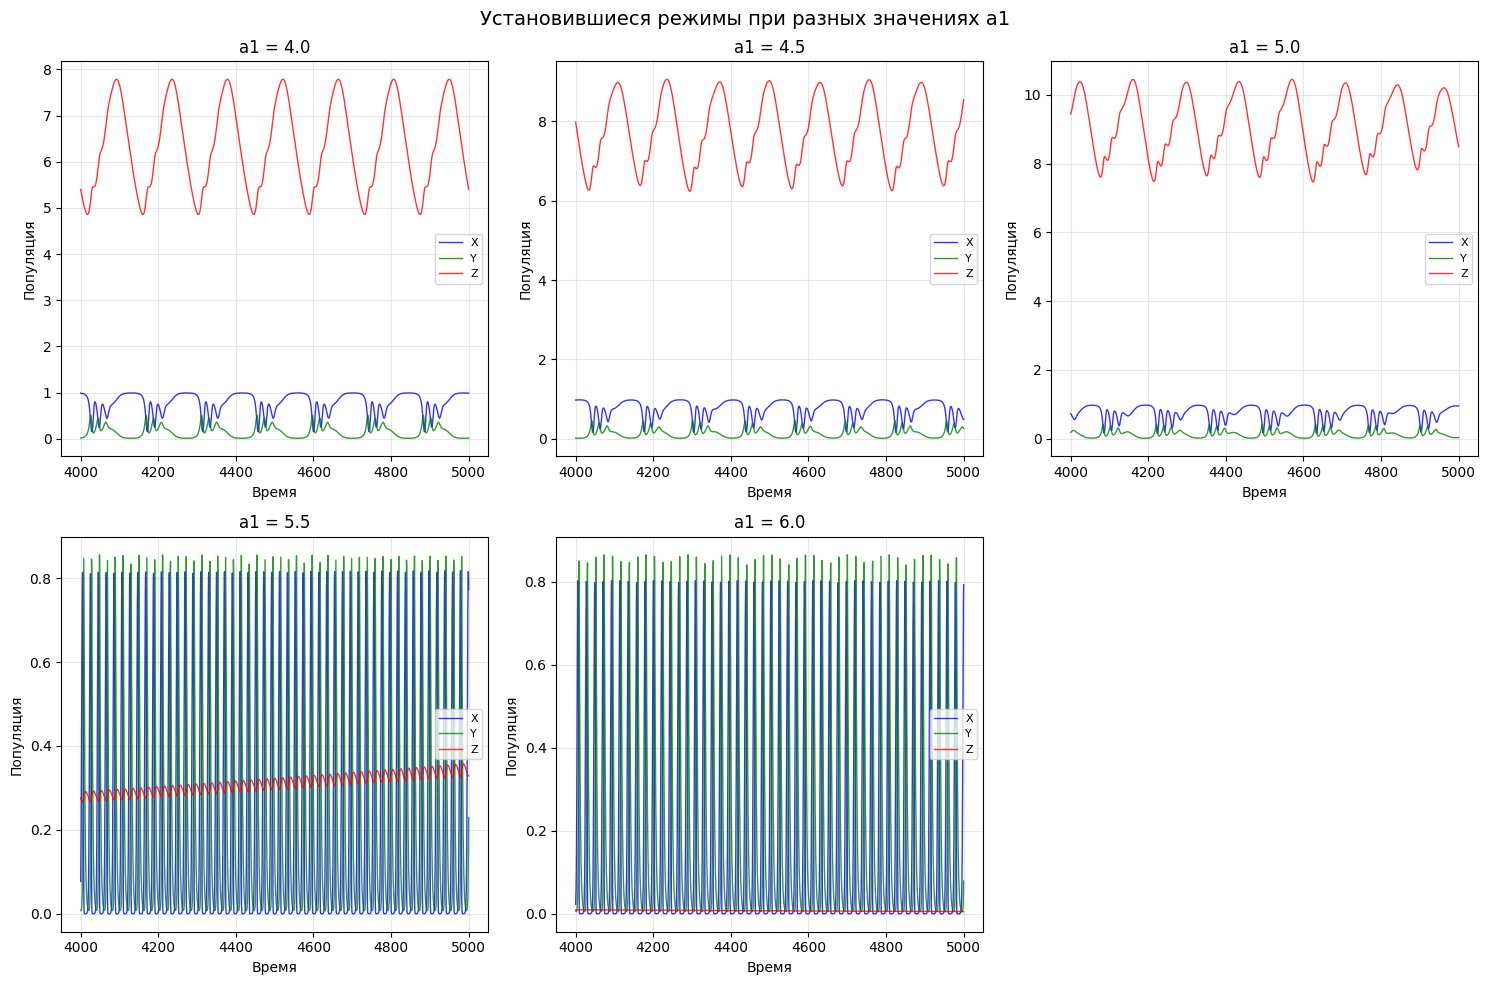

In [4]:
plt.figure(figsize=(15, 10))
for i, a1 in enumerate(a1_values):
    params = params_base.copy()
    params[0] = a1
    t_span = (0, 5000)
    t_eval_full = np.linspace(0, 5000, 10000)
    solution = solve_ivp(food_chain, t_span, initial_conditions, args=(params,), t_eval=t_eval_full, method='RK45', rtol=1e-6, atol=1e-8)
    start_idx = int(0.8 * len(solution.t))
    t_steady = solution.t[start_idx:]
    x_steady = solution.y[0][start_idx:]
    y_steady = solution.y[1][start_idx:]
    z_steady = solution.y[2][start_idx:]
    plt.subplot(2, 3, i+1)
    plt.plot(t_steady, x_steady, 'b-', linewidth=1, alpha=0.8, label='X')
    plt.plot(t_steady, y_steady, 'g-', linewidth=1, alpha=0.8, label='Y') 
    plt.plot(t_steady, z_steady, 'r-', linewidth=1, alpha=0.8, label='Z')
    plt.title(f'a1 = {a1:.1f}')
    plt.xlabel('Время')
    plt.ylabel('Популяция')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
plt.suptitle('Установившиеся режимы при разных значениях a1', fontsize=14)
plt.tight_layout()
plt.show()

Код для анимации эволюции системы во времени

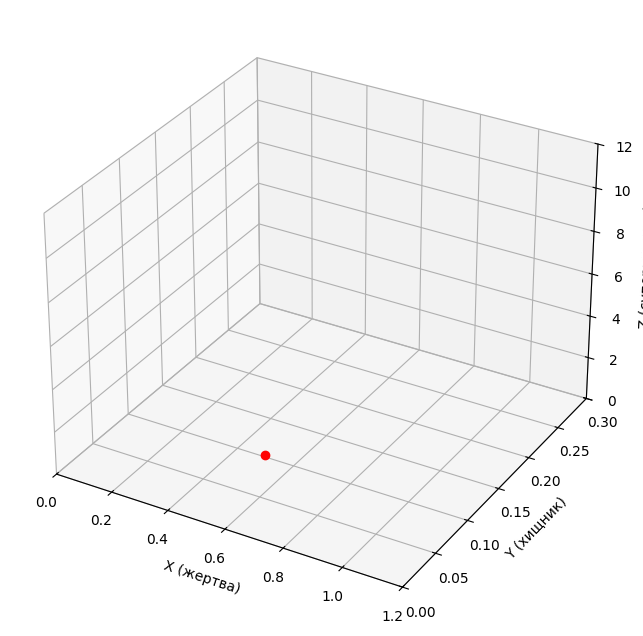

In [5]:
fig_anim = plt.figure(figsize=(10, 8))
ax_3d = fig_anim.add_subplot(111, projection='3d')
t_span_long = (0, 500)
t_eval_long = np.linspace(0, 500, 500)
solution_long = solve_ivp(food_chain, t_span_long, initial_conditions, args=(params_base,), t_eval=t_eval_long, method='RK45', rtol=1e-4, atol=1e-6)
t_anim = solution_long.t
x_anim = solution_long.y[0]
y_anim = solution_long.y[1]
z_anim = solution_long.y[2]
line, = ax_3d.plot([], [], [], 'b-', linewidth=1, alpha=0.7)
point, = ax_3d.plot([], [], [], 'ro', markersize=6)
ax_3d.set_xlim(0, 1.2)
ax_3d.set_ylim(0, 0.3) 
ax_3d.set_zlim(0, 12)
ax_3d.set_xlabel('X (жертва)')
ax_3d.set_ylabel('Y (хищник)')
ax_3d.set_zlabel('Z (суперхищник)')
def animate_steady(frame):
    line.set_data(x_anim[:frame], y_anim[:frame])
    line.set_3d_properties(z_anim[:frame])
    point.set_data([x_anim[frame]], [y_anim[frame]])
    point.set_3d_properties([z_anim[frame]])
    return line, point
anim_steady = FuncAnimation(fig_anim, animate_steady, frames=len(t_anim), interval=50, blit=True, repeat=True)
plt.show()

Бифуркационная диаграмма

Прогресс: 0.0%
Прогресс: 16.7%
Прогресс: 33.3%
Прогресс: 50.0%
Прогресс: 66.7%
Прогресс: 83.3%


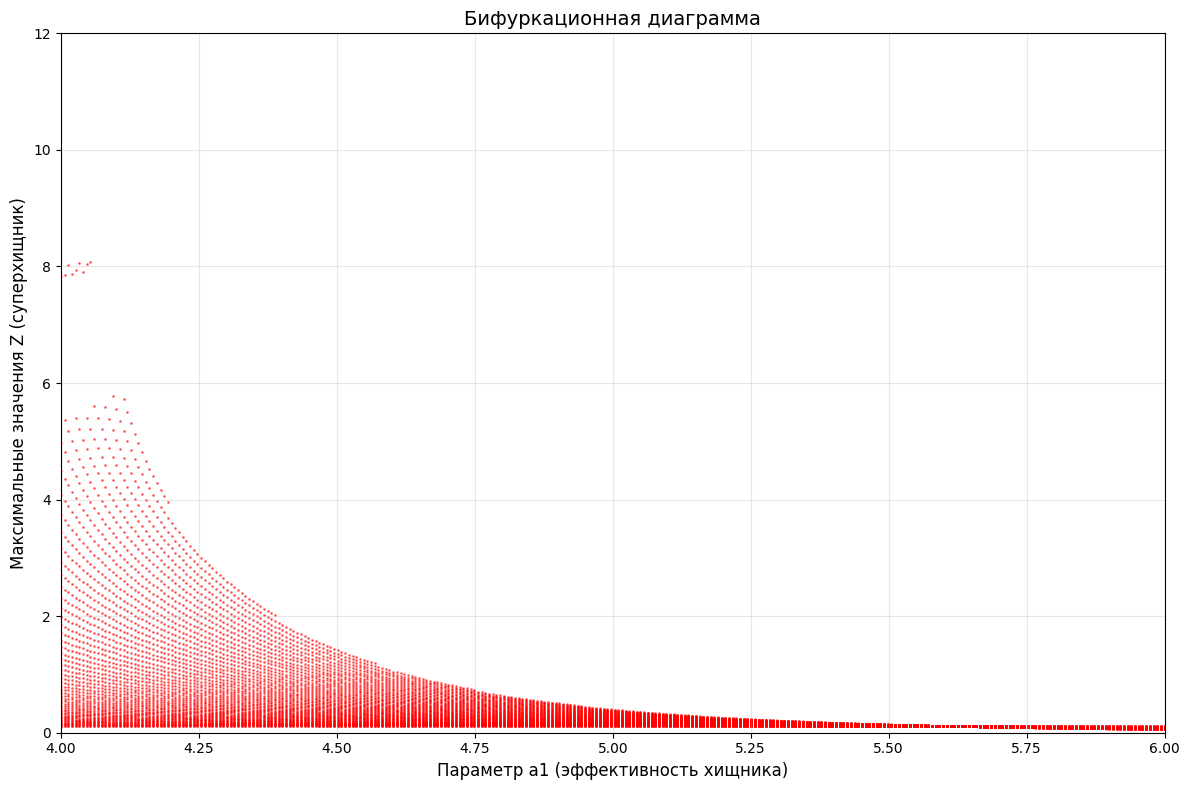

In [7]:
plt.figure(figsize=(12, 8))
a1_range = np.linspace(4.0, 6.0, 300)
maxima_points = []
for i, a1 in enumerate(a1_range):
    if i % 50 == 0:
        print(f"Прогресс: {i/len(a1_range)*100:.1f}%")
    params = params_base.copy()
    params[0] = a1
    t_span = (0, 1000)
    t_eval = np.linspace(0, 1000, 1000)
    solution = solve_ivp(food_chain, t_span, initial_conditions, args=(params,), t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    z = solution.y[2]
    for j in range(1, len(z)-1):
        if z[j] > z[j-1] and z[j] > z[j+1]:
            maxima_points.append((a1, z[j]))
maxima_points = np.array(maxima_points)
plt.scatter(maxima_points[:, 0], maxima_points[:, 1], s=1, alpha=0.5, color='red')
plt.xlabel('Параметр a1 (эффективность хищника)', fontsize=12)
plt.ylabel('Максимальные значения Z (суперхищник)', fontsize=12)
plt.title('Бифуркационная диаграмма', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0, 12)
plt.xlim(4, 6)
plt.tight_layout()
plt.show()

Исследование чувствительности к начальным условиям

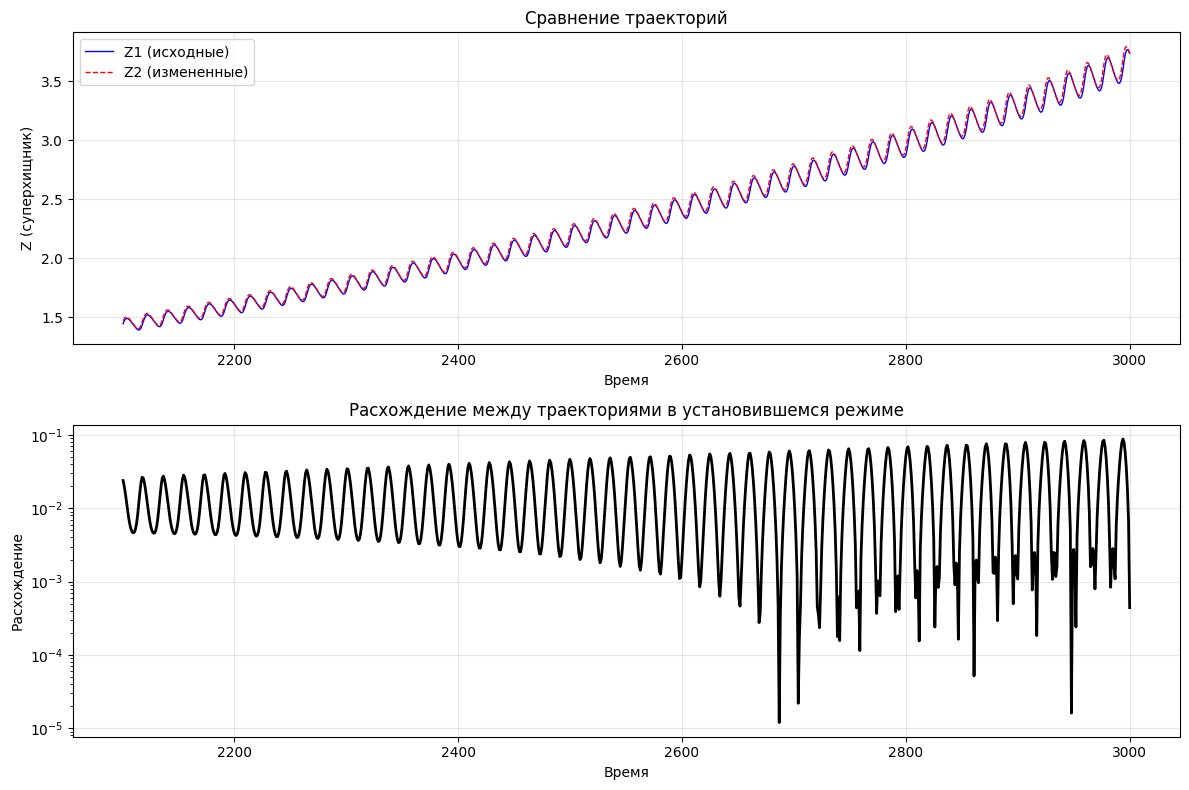

In [8]:
plt.figure(figsize=(12, 8))
solution1 = solve_ivp(food_chain, (0, 3000), initial_conditions, args=(params_base,), t_eval=np.linspace(0, 3000, 3000), method='RK45', rtol=1e-6, atol=1e-8)
initial_conditions2 = [0.501, 0.101, 0.101]
solution2 = solve_ivp(food_chain, (0, 3000), initial_conditions2, args=(params_base,), t_eval=np.linspace(0, 3000, 3000), method='RK45', rtol=1e-6, atol=1e-8)
start_idx_sens = int(0.7 * len(solution1.t))
t_steady_sens = solution1.t[start_idx_sens:]
z1_steady = solution1.y[2][start_idx_sens:]
z2_steady = solution2.y[2][start_idx_sens:]
divergence_steady = np.abs(z1_steady - z2_steady)

plt.subplot(2, 1, 1)
plt.plot(t_steady_sens, z1_steady, 'b-', linewidth=1, label='Z1 (исходные)')
plt.plot(t_steady_sens, z2_steady, 'r--', linewidth=1, label='Z2 (измененные)')
plt.ylabel('Z (суперхищник)')
plt.xlabel('Время')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Сравнение траекторий')

plt.subplot(2, 1, 2)
plt.semilogy(t_steady_sens, divergence_steady, 'k-', linewidth=2)
plt.ylabel('Расхождение')
plt.xlabel('Время')
plt.grid(True, alpha=0.3)
plt.title('Расхождение между траекториями в установившемся режиме')

plt.tight_layout()
plt.show()